# Rectified flow on CelebA-64

t = 0 is noise, t = 1 is data.

    x_t = (1 - t) z + t x1
    target v = x1 - z
    Euler: x_{t+dt} = x_t + v(x_t, t) dt

The architecture lives in `model.py` so this notebook and `trajectory.ipynb`
cannot drift apart. Data, training, and checkpointing are here.

Requires: `pip install datasets` for the HuggingFace CelebA mirror.

In [1]:
import math, time, copy
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model import VelocityNet, to_grid, euler_sample

DEV = torch.device("cuda")
torch.backends.cudnn.benchmark = True
torch.manual_seed(0)

CFG = dict(
    size=64,
    channels=3,
    batch=64,
    steps=40_000,
    lr=2e-4,
    warmup=500,
    ch=64,
    ch_mult=(1, 2, 2, 4),  # 64 -> 32 -> 16 -> 8
    attn_res=(16,),
    ema_decay=0.9995,
    t_dist="uniform",  # or "logit_normal"
    amp=True,
    out="rf_celeba64.pt",
)
CFG

{'size': 64,
 'channels': 3,
 'batch': 64,
 'steps': 40000,
 'lr': 0.0002,
 'warmup': 500,
 'ch': 64,
 'ch_mult': (1, 2, 2, 4),
 'attn_res': (16,),
 'ema_decay': 0.9995,
 't_dist': 'uniform',
 'amp': True,
 'out': 'rf_celeba64.pt'}

## Data

`nielsr/CelebA-faces` is the mirror that actually downloads (the torchvision
CelebA loader hits a broken Google Drive link). Images are 178x218 aligned
faces; `CenterCrop(148)` then `Resize(64)` is the standard crop that keeps the
face and drops most of the background.

First run downloads ~1.4 GB.

In [4]:
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

TF = transforms.Compose(
    [
        transforms.CenterCrop(148),
        transforms.Resize(CFG["size"]),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),  # -> [-1, 1]
    ]
)


class CelebA(Dataset):
    def __init__(self, split="train"):
        self.ds = load_dataset("nielsr/CelebA-faces", split=split)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        return TF(self.ds[i]["image"].convert("RGB")), 0


ds = CelebA()
dl = DataLoader(
    ds,
    batch_size=CFG["batch"],
    shuffle=True,
    num_workers=4,
    drop_last=True,
    pin_memory=True,
    persistent_workers=True,
)


def infinite(loader):
    while True:
        for b in loader:
            yield b


print(len(ds), "images")

dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  462MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  463MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  463MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/202599 [00:00<?, ? examples/s]

202599 images


batch: (64, 3, 64, 64) range: -1.0 1.0


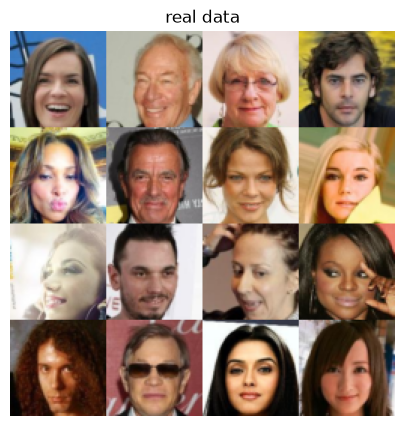

In [5]:
# sanity check the pipeline before spending an hour on it
xb, _ = next(iter(dl))
print("batch:", tuple(xb.shape), "range:", float(xb.min()), float(xb.max()))

plt.figure(figsize=(5, 5))
plt.imshow(to_grid(xb[:16]).numpy())
plt.axis("off")
plt.title("real data")
plt.show()

## Model and EMA

EMA weights are what you sample from. Raw weights on a short budget give
noticeably worse faces.

In [6]:
model = VelocityNet(
    in_ch=CFG["channels"],
    size=CFG["size"],
    ch=CFG["ch"],
    ch_mult=CFG["ch_mult"],
    attn_res=CFG["attn_res"],
    num_classes=None,
).to(DEV)
print(f"params: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")


class EMA:
    def __init__(self, m, decay):
        self.decay = decay
        self.shadow = copy.deepcopy(m).eval().requires_grad_(False)

    @torch.no_grad()
    def update(self, m):
        for s, p in zip(self.shadow.parameters(), m.parameters()):
            s.lerp_(p.detach(), 1.0 - self.decay)
        for s, b in zip(self.shadow.buffers(), m.buffers()):
            s.copy_(b)


ema = EMA(model, CFG["ema_decay"])

opt = torch.optim.AdamW(
    model.parameters(), lr=CFG["lr"], weight_decay=0.0, betas=(0.9, 0.99)
)
sched = torch.optim.lr_scheduler.LambdaLR(
    opt,
    lambda i: (
        min(1.0, (i + 1) / CFG["warmup"])
        * (0.5 * (1 + math.cos(math.pi * min(1.0, i / CFG["steps"]))))
    ),
)


def sample_t(n, device, mode):
    if mode == "uniform":
        return torch.rand(n, device=device)
    if mode == "logit_normal":
        return torch.sigmoid(torch.randn(n, device=device))
    raise ValueError(mode)

params: 6.39M


## Training loop

Re-running this cell continues from where it stopped, so you can train in
chunks and look at previews in between. Set `CFG["steps"]` to the total you
want and interrupt whenever.

step    250/40000  loss 0.9537  lr 1.00e-04  5.1 it/s
step    500/40000  loss 0.2343  lr 2.00e-04  7.4 it/s
step    750/40000  loss 0.1605  lr 2.00e-04  7.4 it/s
step   1000/40000  loss 0.1444  lr 2.00e-04  7.4 it/s
step   1250/40000  loss 0.1371  lr 2.00e-04  7.3 it/s
step   1500/40000  loss 0.1346  lr 1.99e-04  7.3 it/s
step   1750/40000  loss 0.1310  lr 1.99e-04  7.4 it/s
step   2000/40000  loss 0.1277  lr 1.99e-04  7.4 it/s
step   2250/40000  loss 0.1267  lr 1.98e-04  7.4 it/s
step   2500/40000  loss 0.1251  lr 1.98e-04  7.3 it/s


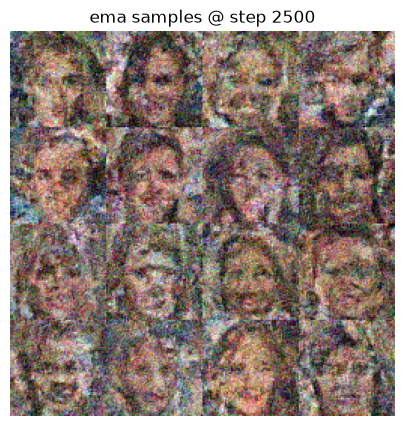

step   2750/40000  loss 0.1247  lr 1.98e-04  6.5 it/s
step   3000/40000  loss 0.1240  lr 1.97e-04  7.2 it/s
step   3250/40000  loss 0.1220  lr 1.97e-04  7.2 it/s
step   3500/40000  loss 0.1209  lr 1.96e-04  7.2 it/s
step   3750/40000  loss 0.1211  lr 1.96e-04  7.2 it/s
step   4000/40000  loss 0.1191  lr 1.95e-04  7.3 it/s
step   4250/40000  loss 0.1177  lr 1.94e-04  7.2 it/s
step   4500/40000  loss 0.1184  lr 1.94e-04  7.3 it/s
step   4750/40000  loss 0.1176  lr 1.93e-04  7.3 it/s
step   5000/40000  loss 0.1190  lr 1.92e-04  7.3 it/s


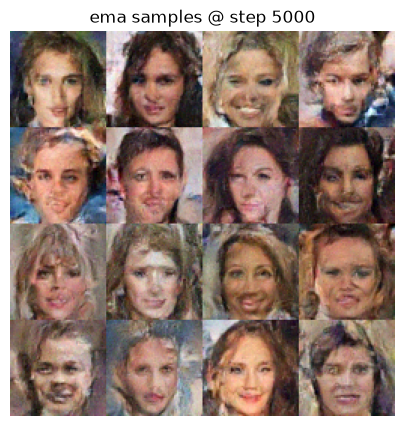

step   5250/40000  loss 0.1193  lr 1.92e-04  7.2 it/s
step   5500/40000  loss 0.1170  lr 1.91e-04  7.3 it/s
step   5750/40000  loss 0.1170  lr 1.90e-04  7.3 it/s
step   6000/40000  loss 0.1159  lr 1.89e-04  7.3 it/s
step   6250/40000  loss 0.1170  lr 1.88e-04  7.3 it/s
step   6500/40000  loss 0.1144  lr 1.87e-04  7.3 it/s
step   6750/40000  loss 0.1137  lr 1.86e-04  7.3 it/s
step   7000/40000  loss 0.1155  lr 1.85e-04  7.3 it/s
step   7250/40000  loss 0.1144  lr 1.84e-04  7.3 it/s
step   7500/40000  loss 0.1161  lr 1.83e-04  7.3 it/s


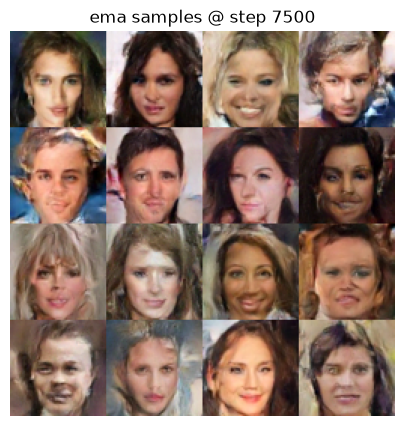

step   7750/40000  loss 0.1153  lr 1.82e-04  7.1 it/s
step   8000/40000  loss 0.1138  lr 1.81e-04  7.2 it/s
step   8250/40000  loss 0.1144  lr 1.80e-04  7.3 it/s
step   8500/40000  loss 0.1141  lr 1.79e-04  7.3 it/s
step   8750/40000  loss 0.1143  lr 1.77e-04  7.3 it/s
step   9000/40000  loss 0.1135  lr 1.76e-04  7.3 it/s
step   9250/40000  loss 0.1117  lr 1.75e-04  7.2 it/s
step   9500/40000  loss 0.1131  lr 1.73e-04  7.2 it/s
step   9750/40000  loss 0.1126  lr 1.72e-04  7.3 it/s
step  10000/40000  loss 0.1135  lr 1.71e-04  7.2 it/s


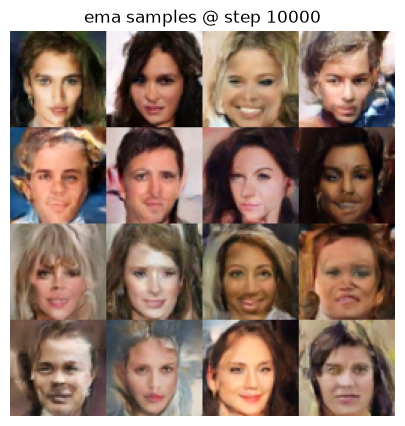

step  10250/40000  loss 0.1140  lr 1.69e-04  7.1 it/s
step  10500/40000  loss 0.1124  lr 1.68e-04  7.2 it/s
step  10750/40000  loss 0.1122  lr 1.66e-04  7.2 it/s
step  11000/40000  loss 0.1118  lr 1.65e-04  7.2 it/s
step  11250/40000  loss 0.1128  lr 1.63e-04  7.3 it/s
step  11500/40000  loss 0.1116  lr 1.62e-04  7.2 it/s
step  11750/40000  loss 0.1107  lr 1.60e-04  7.2 it/s
step  12000/40000  loss 0.1117  lr 1.59e-04  7.3 it/s
step  12250/40000  loss 0.1114  lr 1.57e-04  7.3 it/s
step  12500/40000  loss 0.1125  lr 1.56e-04  7.3 it/s


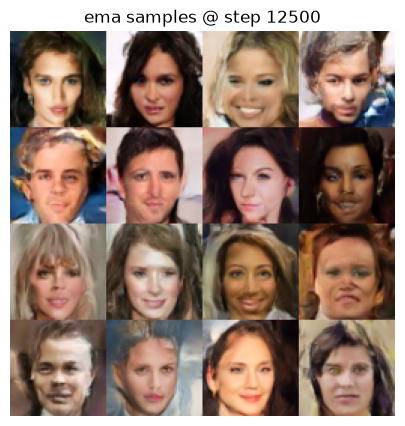

step  12750/40000  loss 0.1128  lr 1.54e-04  7.1 it/s
step  13000/40000  loss 0.1114  lr 1.52e-04  7.3 it/s
step  13250/40000  loss 0.1115  lr 1.51e-04  7.3 it/s
step  13500/40000  loss 0.1111  lr 1.49e-04  7.3 it/s
step  13750/40000  loss 0.1115  lr 1.47e-04  7.2 it/s
step  14000/40000  loss 0.1105  lr 1.45e-04  7.2 it/s
step  14250/40000  loss 0.1092  lr 1.44e-04  7.3 it/s
step  14500/40000  loss 0.1109  lr 1.42e-04  7.3 it/s
step  14750/40000  loss 0.1101  lr 1.40e-04  7.3 it/s
step  15000/40000  loss 0.1114  lr 1.38e-04  7.3 it/s


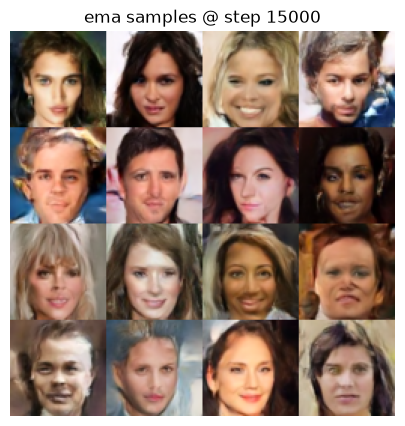

step  15250/40000  loss 0.1121  lr 1.36e-04  7.1 it/s
step  15500/40000  loss 0.1102  lr 1.35e-04  7.2 it/s
step  15750/40000  loss 0.1104  lr 1.33e-04  7.3 it/s
step  16000/40000  loss 0.1096  lr 1.31e-04  7.2 it/s
step  16250/40000  loss 0.1103  lr 1.29e-04  7.2 it/s
step  16500/40000  loss 0.1099  lr 1.27e-04  7.2 it/s
step  16750/40000  loss 0.1079  lr 1.25e-04  7.2 it/s
step  17000/40000  loss 0.1097  lr 1.23e-04  7.2 it/s
step  17250/40000  loss 0.1087  lr 1.21e-04  7.2 it/s
step  17500/40000  loss 0.1106  lr 1.20e-04  7.2 it/s


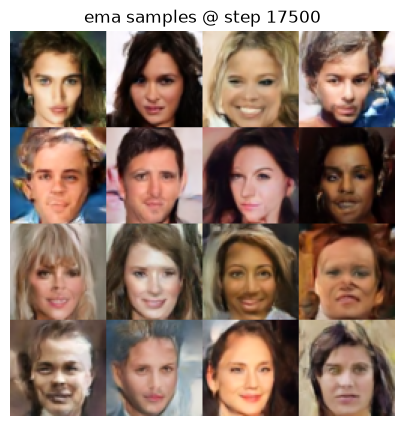

step  17750/40000  loss 0.1107  lr 1.18e-04  7.1 it/s
step  18000/40000  loss 0.1100  lr 1.16e-04  7.2 it/s
step  18250/40000  loss 0.1093  lr 1.14e-04  7.2 it/s
step  18500/40000  loss 0.1087  lr 1.12e-04  7.2 it/s
step  18750/40000  loss 0.1095  lr 1.10e-04  7.2 it/s
step  19000/40000  loss 0.1089  lr 1.08e-04  7.2 it/s
step  19250/40000  loss 0.1071  lr 1.06e-04  7.2 it/s
step  19500/40000  loss 0.1088  lr 1.04e-04  7.2 it/s
step  19750/40000  loss 0.1080  lr 1.02e-04  7.2 it/s
step  20000/40000  loss 0.1098  lr 1.00e-04  7.2 it/s


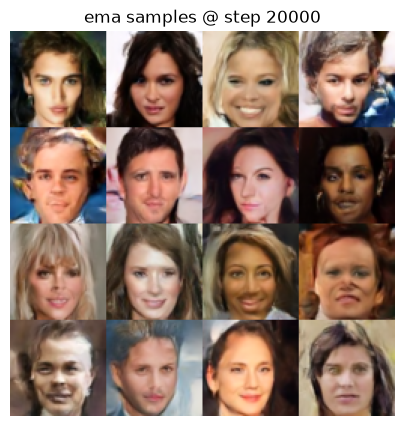

step  20250/40000  loss 0.1099  lr 9.80e-05  7.1 it/s
step  20500/40000  loss 0.1085  lr 9.61e-05  7.2 it/s
step  20750/40000  loss 0.1083  lr 9.41e-05  7.2 it/s
step  21000/40000  loss 0.1083  lr 9.22e-05  7.2 it/s
step  21250/40000  loss 0.1093  lr 9.02e-05  7.2 it/s
step  21500/40000  loss 0.1083  lr 8.82e-05  7.2 it/s
step  21750/40000  loss 0.1069  lr 8.63e-05  7.2 it/s
step  22000/40000  loss 0.1081  lr 8.44e-05  7.2 it/s
step  22250/40000  loss 0.1074  lr 8.24e-05  7.2 it/s
step  22500/40000  loss 0.1091  lr 8.05e-05  7.2 it/s


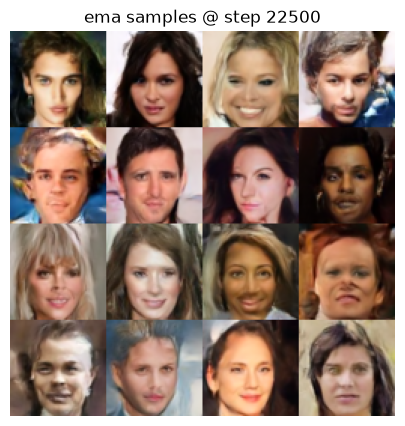

step  22750/40000  loss 0.1096  lr 7.86e-05  7.1 it/s
step  23000/40000  loss 0.1084  lr 7.67e-05  7.2 it/s
step  23250/40000  loss 0.1080  lr 7.48e-05  7.2 it/s
step  23500/40000  loss 0.1074  lr 7.29e-05  7.2 it/s
step  23750/40000  loss 0.1081  lr 7.10e-05  7.2 it/s
step  24000/40000  loss 0.1075  lr 6.91e-05  7.2 it/s
step  24250/40000  loss 0.1066  lr 6.72e-05  7.2 it/s
step  24500/40000  loss 0.1078  lr 6.54e-05  7.3 it/s
step  24750/40000  loss 0.1073  lr 6.36e-05  7.3 it/s
step  25000/40000  loss 0.1085  lr 6.17e-05  7.3 it/s


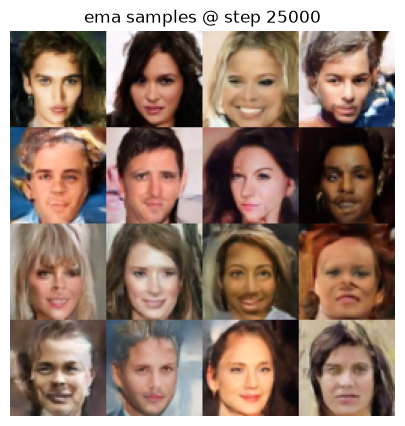

step  25250/40000  loss 0.1087  lr 5.99e-05  7.2 it/s
step  25500/40000  loss 0.1075  lr 5.81e-05  7.3 it/s
step  25750/40000  loss 0.1071  lr 5.64e-05  7.3 it/s
step  26000/40000  loss 0.1069  lr 5.46e-05  7.3 it/s
step  26250/40000  loss 0.1077  lr 5.29e-05  7.3 it/s
step  26500/40000  loss 0.1064  lr 5.11e-05  7.3 it/s
step  26750/40000  loss 0.1054  lr 4.94e-05  7.3 it/s
step  27000/40000  loss 0.1064  lr 4.78e-05  7.3 it/s
step  27250/40000  loss 0.1072  lr 4.61e-05  7.3 it/s
step  27500/40000  loss 0.1086  lr 4.44e-05  7.3 it/s


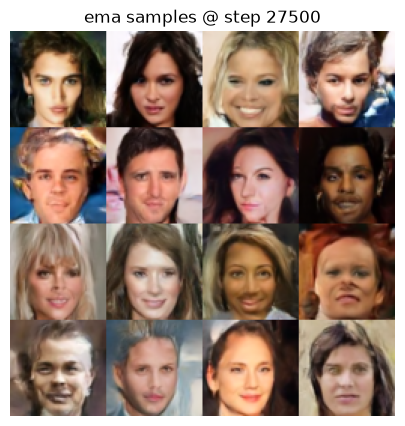

step  27750/40000  loss 0.1080  lr 4.28e-05  7.2 it/s
step  28000/40000  loss 0.1076  lr 4.12e-05  7.3 it/s
step  28250/40000  loss 0.1069  lr 3.96e-05  7.3 it/s
step  28500/40000  loss 0.1060  lr 3.81e-05  7.3 it/s
step  28750/40000  loss 0.1075  lr 3.66e-05  7.3 it/s
step  29000/40000  loss 0.1061  lr 3.51e-05  7.3 it/s
step  29250/40000  loss 0.1051  lr 3.36e-05  7.3 it/s
step  29500/40000  loss 0.1068  lr 3.21e-05  7.3 it/s
step  29750/40000  loss 0.1059  lr 3.07e-05  7.3 it/s
step  30000/40000  loss 0.1072  lr 2.93e-05  7.3 it/s


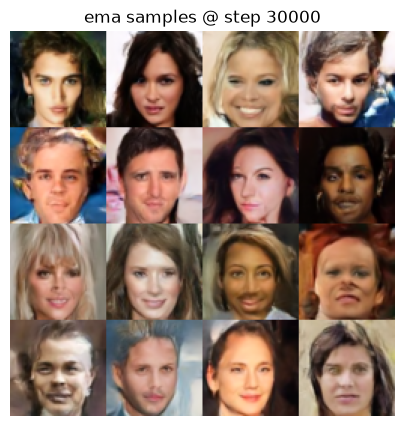

step  30250/40000  loss 0.1078  lr 2.79e-05  7.2 it/s
step  30500/40000  loss 0.1069  lr 2.66e-05  7.3 it/s
step  30750/40000  loss 0.1068  lr 2.52e-05  7.3 it/s
step  31000/40000  loss 0.1062  lr 2.40e-05  7.3 it/s
step  31250/40000  loss 0.1071  lr 2.27e-05  7.3 it/s
step  31500/40000  loss 0.1061  lr 2.15e-05  7.3 it/s
step  31750/40000  loss 0.1043  lr 2.03e-05  7.3 it/s
step  32000/40000  loss 0.1062  lr 1.91e-05  7.3 it/s
step  32250/40000  loss 0.1055  lr 1.80e-05  7.3 it/s
step  32500/40000  loss 0.1070  lr 1.69e-05  7.3 it/s


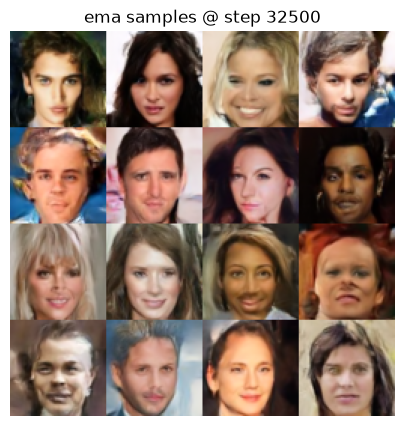

step  32750/40000  loss 0.1076  lr 1.58e-05  7.1 it/s
step  33000/40000  loss 0.1059  lr 1.47e-05  7.3 it/s
step  33250/40000  loss 0.1058  lr 1.37e-05  7.3 it/s
step  33500/40000  loss 0.1057  lr 1.28e-05  7.2 it/s
step  33750/40000  loss 0.1068  lr 1.18e-05  7.3 it/s
step  34000/40000  loss 0.1058  lr 1.09e-05  7.3 it/s
step  34250/40000  loss 0.1047  lr 1.00e-05  7.3 it/s
step  34500/40000  loss 0.1059  lr 9.19e-06  7.2 it/s
step  34750/40000  loss 0.1052  lr 8.38e-06  7.3 it/s
step  35000/40000  loss 0.1066  lr 7.61e-06  7.3 it/s


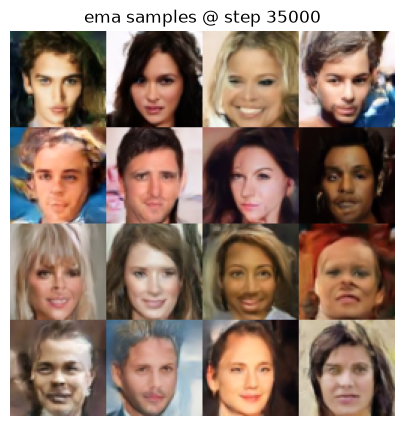

step  35250/40000  loss 0.1069  lr 6.88e-06  7.1 it/s
step  35500/40000  loss 0.1057  lr 6.18e-06  7.3 it/s
step  35750/40000  loss 0.1060  lr 5.52e-06  7.3 it/s
step  36000/40000  loss 0.1054  lr 4.89e-06  7.2 it/s
step  36250/40000  loss 0.1062  lr 4.31e-06  7.2 it/s
step  36500/40000  loss 0.1049  lr 3.75e-06  7.3 it/s
step  36750/40000  loss 0.1042  lr 3.24e-06  7.3 it/s
step  37000/40000  loss 0.1059  lr 2.76e-06  7.3 it/s
step  37250/40000  loss 0.1054  lr 2.32e-06  7.3 it/s
step  37500/40000  loss 0.1067  lr 1.92e-06  7.3 it/s


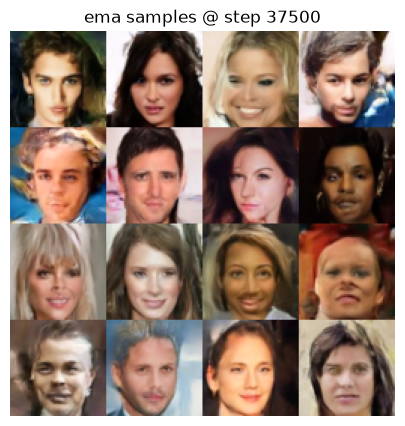

step  37750/40000  loss 0.1069  lr 1.56e-06  7.1 it/s
step  38000/40000  loss 0.1055  lr 1.23e-06  7.3 it/s
step  38250/40000  loss 0.1057  lr 9.43e-07  7.3 it/s
step  38500/40000  loss 0.1051  lr 6.93e-07  7.2 it/s
step  38750/40000  loss 0.1061  lr 4.82e-07  7.3 it/s
step  39000/40000  loss 0.1051  lr 3.08e-07  7.3 it/s
step  39250/40000  loss 0.1037  lr 1.73e-07  7.3 it/s
step  39500/40000  loss 0.1053  lr 7.71e-08  7.3 it/s
step  39750/40000  loss 0.1051  lr 1.93e-08  7.3 it/s
step  40000/40000  loss 0.1066  lr 0.00e+00  7.3 it/s


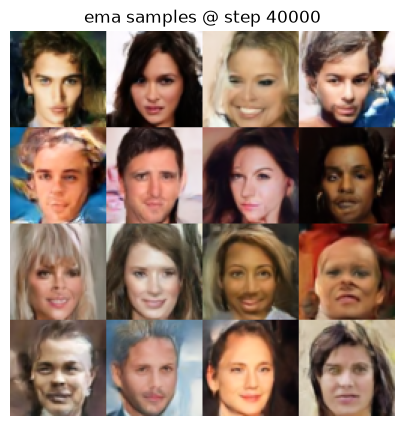

In [7]:
SHAPE = (CFG["channels"], CFG["size"], CFG["size"])
it = infinite(dl)
step = globals().get("step", 0)
amp = dict(device_type="cuda", dtype=torch.bfloat16, enabled=CFG["amp"])


def preview(n=16, T=50):
    x = euler_sample(ema.shadow, n, T, DEV, SHAPE, seed=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(to_grid(x).cpu().numpy())
    plt.axis("off")
    plt.title(f"ema samples @ step {step}")
    plt.show()


running, t0 = 0.0, time.perf_counter()
LOG_EVERY, PREVIEW_EVERY = 250, 2500

try:
    while step < CFG["steps"]:
        x1, _ = next(it)
        x1 = x1.to(DEV, non_blocking=True)
        z = torch.randn_like(x1)
        t = sample_t(x1.shape[0], DEV, CFG["t_dist"])
        tb = t[:, None, None, None]
        xt = (1 - tb) * z + tb * x1

        with torch.autocast(**amp):
            loss = F.mse_loss(model(xt, t).float(), x1 - z)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
        ema.update(model)

        running += loss.item()
        step += 1

        if step % LOG_EVERY == 0:
            dt = time.perf_counter() - t0
            print(
                f"step {step:>6}/{CFG['steps']}  loss {running / LOG_EVERY:.4f}"
                f"  lr {sched.get_last_lr()[0]:.2e}  {LOG_EVERY / dt:.1f} it/s"
            )
            running, t0 = 0.0, time.perf_counter()

        if step % PREVIEW_EVERY == 0:
            preview()
except KeyboardInterrupt:
    print("interrupted at step", step)

## Save

`meta` is what `trajectory.ipynb` reads to size its buffers.

In [8]:
torch.save(
    {
        "model": model.state_dict(),
        "ema": ema.shadow.state_dict(),
        "config": model.cfg,
        "meta": {
            "channels": CFG["channels"],
            "size": CFG["size"],
            "num_classes": None,
            "name": "celeba64",
        },
        "step": step,
    },
    CFG["out"],
)
print("saved", CFG["out"], "at step", step)

saved rf_celeba64.pt at step 40000


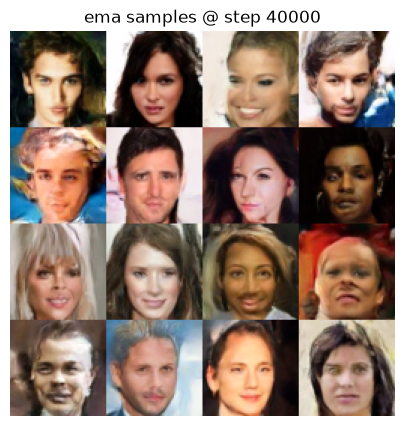

In [10]:
# final look, more Euler steps
preview(n=16, T=1_000)